# DBSCAN Clustering & Epsilon Tuning

**Goal:** Cluster NYC FHV pickup locations using DBSCAN to identify high-density ride request zones, then tune hyperparameters for pooling quality.

**Data source:** `../Data/raw/merged_trip_emissions_coordinates.csv`  \n
Columns used: `pickup_lat`, `pickup_lon`, `pickup_datetime`, `PULocationID`, `trip_miles`, `co2TailpipeGpm`, `co2_total_g`, `shared_match_flag`

**Features used for clustering:**
- `pickup_lat`, `pickup_lon` — geographic centroid of the pickup zone
- `hour_sin`, `hour_cos` — cyclic encoding of hour-of-day from `pickup_datetime`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120

## Load Data

In [2]:
DATA_PATH = "../Data/raw/merged_trip_emissions_coordinates.csv"
SUBSET_N  = 10000 
RANDOM_STATE = 42

df_full = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Full dataset: {len(df_full):,} rows  |  {df_full.shape[1]} columns")
print("Columns:", df_full.columns.tolist())

def preprocess(df):
    df = df.copy()

    # Coerce types
    df["pickup_datetime"]  = pd.to_datetime(df["pickup_datetime"],  errors="coerce")
    df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"], errors="coerce")
    df["pickup_lat"]       = pd.to_numeric(df["pickup_lat"],        errors="coerce")
    df["pickup_lon"]       = pd.to_numeric(df["pickup_lon"],        errors="coerce")
    df["trip_miles"]       = pd.to_numeric(df["trip_miles"],        errors="coerce")
    df["co2TailpipeGpm"]   = pd.to_numeric(df["co2TailpipeGpm"],    errors="coerce")
    df["co2_total_g"]      = pd.to_numeric(df["co2_total_g"],       errors="coerce")

    df = df.dropna(subset=["pickup_lat", "pickup_lon", "pickup_datetime", "PULocationID"])

    df[["pickup_lat", "pickup_lon", "trip_miles", "co2TailpipeGpm", "co2_total_g"]].describe().round(3)
    print(f"Full dataset : {len(df_full):,} rows")
    print(f"Working subset after cleaning: {len(df):,} rows")

    # Time features
    df["pickup_hour"] = df["pickup_datetime"].dt.hour
    df["hour_sin"] = np.sin(2 * np.pi * df["pickup_hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["pickup_hour"] / 24)

    return df

# Reproducible sample
df_train = preprocess(df_full.sample(n = SUBSET_N, random_state = RANDOM_STATE).reset_index(drop=True))


Full dataset: 2,062,185 rows  |  28 columns
Columns: ['request_datetime', 'on_scene_datetime', 'pickup_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'airport_fee', 'tips', 'driver_pay', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'VClass', 'co2TailpipeGpm', 'city08', 'fuelCost08', 'fuelType', 'pickup_day', 'co2_total_g', 'time_gap_sec', 'pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon']
Full dataset : 2,062,185 rows
Working subset after cleaning: 10,000 rows


## Feature Engineering

In [3]:
features = ["pickup_lat", "pickup_lon", "hour_sin", "hour_cos"]
X_train    = df_train[features].values

# Standardize so lat/lon (~0.1° std) and trig features (~0.7 std) are comparable
scaler = StandardScaler()
X      = scaler.fit_transform(X_train)

print(f"Feature matrix shape: {X.shape}")
print(f"Pickup hours range  : {df_train['pickup_hour'].min()}h – {df_train['pickup_hour'].max()}h")
print(f"Lat range  : {df_train['pickup_lat'].min():.4f} – {df_train['pickup_lat'].max():.4f}")
print(f"Lon range  : {df_train['pickup_lon'].min():.4f} – {df_train['pickup_lon'].max():.4f}")
pd.DataFrame(X, columns=features).describe().round(3)

Feature matrix shape: (10000, 4)
Pickup hours range  : 0h – 23h
Lat range  : 131946.8866 – 267014.1903
Lon range  : 931871.3701 – 1064321.6844


,pickup_lat,pickup_lon,hour_sin,hour_cos
count,10000.000,10000.000,10000.000,10000.000
mean,-0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000
min,-3.298,-4.227,-1.275,-1.657
25%,-0.698,-0.776,-0.852,-0.938
50%,-0.041,-0.194,-0.205,0.154
75%,0.535,0.457,0.890,1.028
max,2.628,3.821,1.611,1.220


## k-Distance Plot, Choosing Epsilon

`min_samples = 2 * n_features`.  

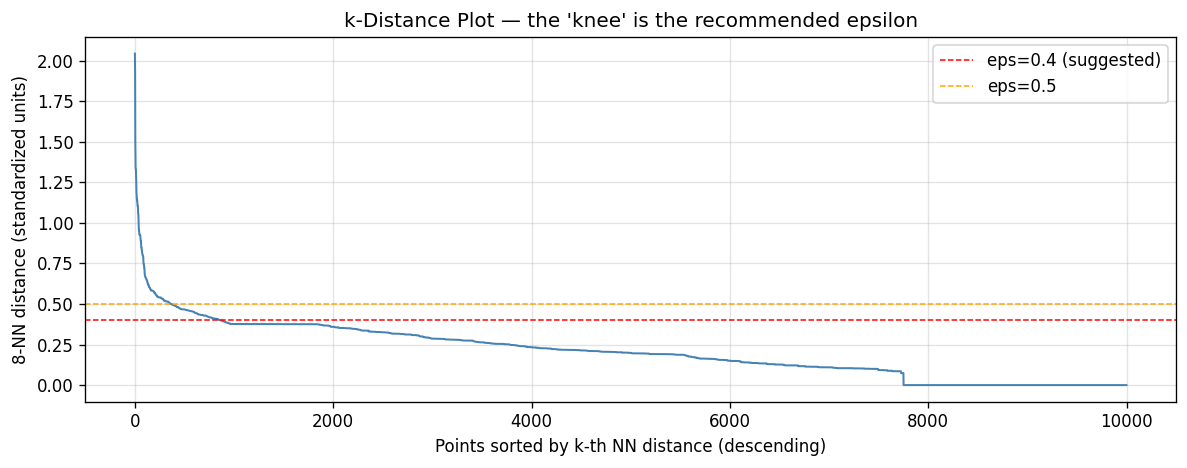

Rough knee estimate (5th pct of sorted distances): 0.466
Set EPSILON in the next cell to this value (or the visual knee from the plot)


In [4]:
MIN_SAMPLES = 2 * X.shape[1]  

nbrs        = NearestNeighbors(n_neighbors=MIN_SAMPLES, algorithm="ball_tree").fit(X)
distances, _= nbrs.kneighbors(X)
k_distances = np.sort(distances[:, -1])[::-1]   # k-th NN distance, descending

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, linewidth=1.2, color="steelblue")
ax.axhline(y=0.4, color="red",    linestyle="--", linewidth=0.9, label="eps=0.4 (suggested)")
ax.axhline(y=0.5, color="orange", linestyle="--", linewidth=0.9, label="eps=0.5")
ax.set_xlabel("Points sorted by k-th NN distance (descending)")
ax.set_ylabel(f"{MIN_SAMPLES}-NN distance (standardized units)")
ax.set_title("k-Distance Plot — the 'knee' is the recommended epsilon")
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig("figures/kdistance_plot.png", bbox_inches="tight")
plt.show()

knee_approx = k_distances[int(len(k_distances) * 0.05)]   # ~5th percentile as rough knee
print(f"Rough knee estimate (5th pct of sorted distances): {knee_approx:.3f}")
print("Set EPSILON in the next cell to this value (or the visual knee from the plot)")

## Run DBSCAN

In [5]:
EPSILON     = 0.333 
MIN_SAMPLES = 8   
# ──────────────────────────────────────────────────────────────────────────

db = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES, algorithm="ball_tree", n_jobs=-1)
df_train["dbscan_cluster"] = db.fit_predict(X)

n_clusters = len(set(df_train["dbscan_cluster"])) - (1 if -1 in df_train["dbscan_cluster"].values else 0)
noise_pct  = (df_train["dbscan_cluster"] == -1).mean() * 100
clustered  = df_train[df_train["dbscan_cluster"] != -1]

if n_clusters > 1 and len(clustered) > 1:
    sil = silhouette_score(
        X[clustered.index], clustered["dbscan_cluster"],
        sample_size=min(5000, len(clustered)), random_state=42
    )
else:
    sil = float("nan")

print(f"eps={EPSILON}, min_samples={MIN_SAMPLES}")
print(f"  Clusters found   : {n_clusters}")
print(f"  Noise points     : {noise_pct:.1f}%  ({int(noise_pct/100*len(df_train)):,} rows)")
print(f"  Clustered points : {len(clustered):,}")
if not np.isnan(sil):
    print(f"  Silhouette score : {sil:.4f}  (target > 0.3)")
else:
    print("  Silhouette score : N/A (need >1 cluster)")

eps=0.333, min_samples=8
  Clusters found   : 80
  Noise points     : 15.8%  (1,581 rows)
  Clustered points : 8,419
  Silhouette score : -0.0963  (target > 0.3)


## Epsilon Grid Search

Sweep a range of epsilon values and record metrics.

 eps  n_clusters  noise_pct  silhouette
0.25         172       32.1      0.1691
0.30         122       22.9      0.0085
0.35          87       13.6     -0.1091
0.40          21        3.6     -0.2088
0.45           5        2.3     -0.1180
0.50           4        1.5      0.0455
0.55           1        1.0         NaN
0.60           1        0.8         NaN

Best silhouette: eps=0.25, n_clusters=172, silhouette=0.1691


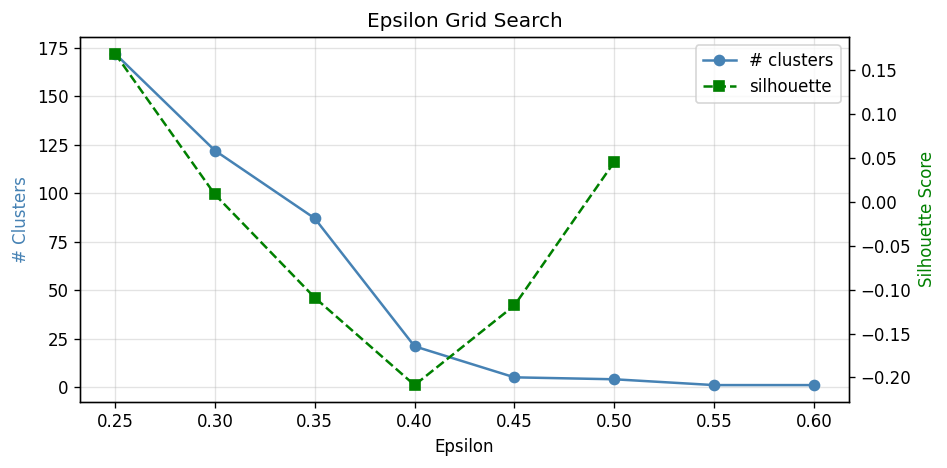

In [6]:
eps_values   = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
tune_results = []

for eps in eps_values:
    labels  = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, algorithm="ball_tree", n_jobs=-1).fit_predict(X)
    n_cl    = len(set(labels)) - (1 if -1 in labels else 0)
    noise   = (labels == -1).mean() * 100
    mask    = labels != -1
    if n_cl > 1 and mask.sum() > 1:
        sil_val = silhouette_score(X[mask], labels[mask], sample_size=min(5000, mask.sum()), random_state=42)
    else:
        sil_val = float("nan")
    tune_results.append({
        "eps":        eps,
        "n_clusters": n_cl,
        "noise_pct":  round(noise, 1),
        "silhouette": round(sil_val, 4) if not np.isnan(sil_val) else None,
    })

tune_df = pd.DataFrame(tune_results)
print(tune_df.to_string(index=False))

best = tune_df.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False).iloc[0]
print(f"\nBest silhouette: eps={best['eps']}, n_clusters={int(best['n_clusters'])}, silhouette={best['silhouette']}")

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(tune_df["eps"], tune_df["n_clusters"],  "o-",  color="steelblue", label="# clusters")
ax2.plot(tune_df["eps"], tune_df["silhouette"],   "s--", color="green",     label="silhouette")
ax1.set_xlabel("Epsilon"); ax1.set_ylabel("# Clusters", color="steelblue")
ax2.set_ylabel("Silhouette Score", color="green")
ax1.set_title("Epsilon Grid Search")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax1.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig("figures/eps_grid_search.png", bbox_inches="tight")
plt.show()

## Cluster Size Distribution & Emissions Profile

Understand how many trips fall in each cluster and what their CO₂ footprint looks like.  
Clusters with many trips in a small geographic area are the best pooling candidates.

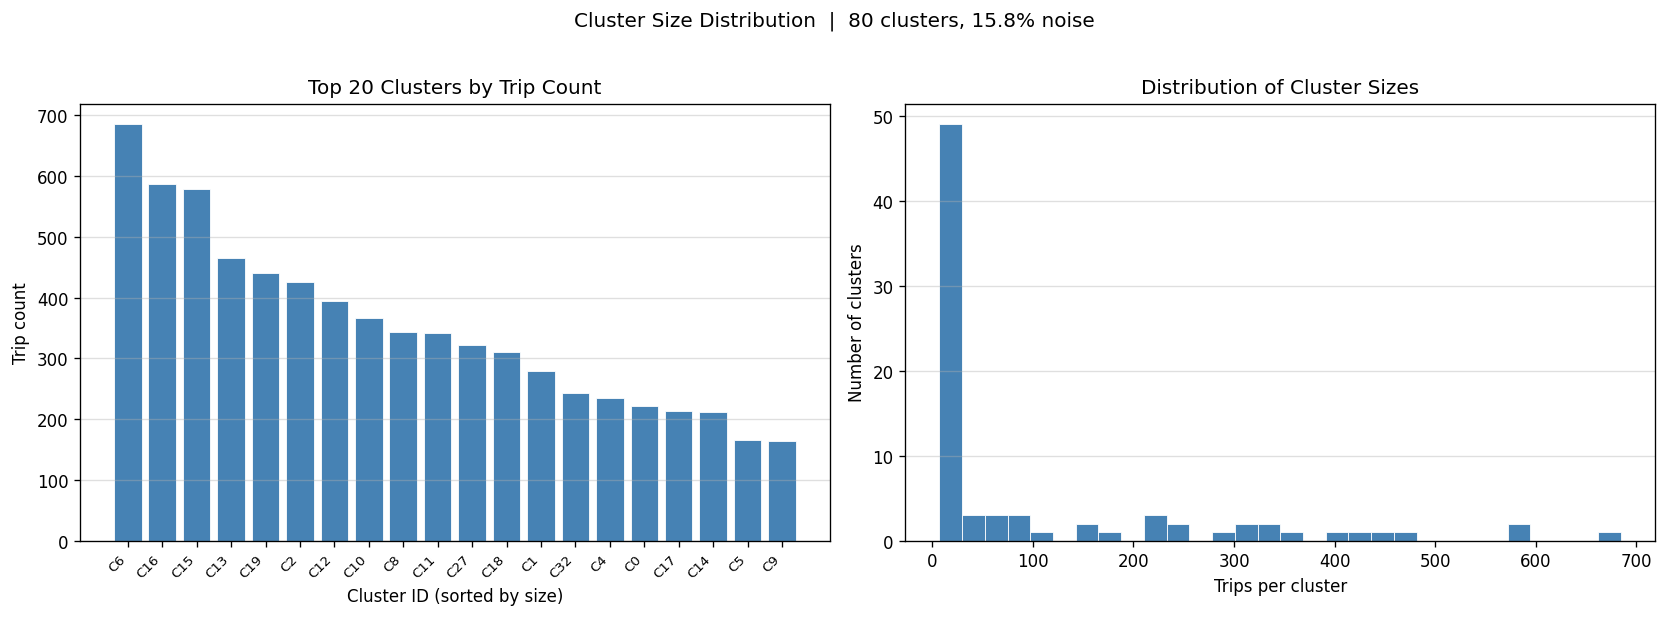

Median cluster size : 16 trips
Largest cluster     : 685 trips  (Cluster 6)
Smallest cluster    : 7 trips


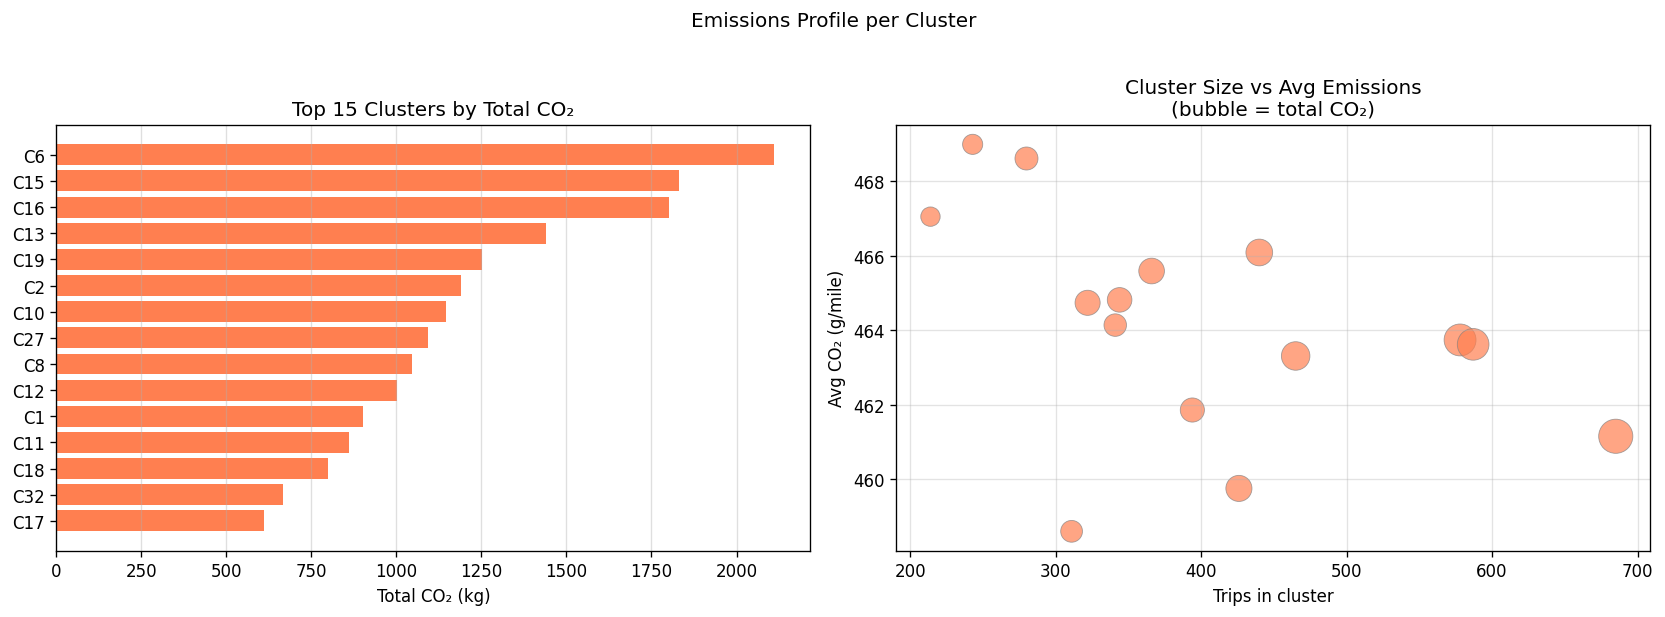


Top 5 highest-emission clusters:
 dbscan_cluster  n_trips  avg_co2_g_mi  total_co2_kg  avg_trip_miles
              6      685    461.158173   2111.279619        6.695861
             15      578    463.742509   1830.201826        6.831673
             16      587    463.624388   1800.529485        6.577293
             13      465    463.312499   1440.762332        6.651970
             19      440    466.089147   1252.381855        6.088275


In [7]:
clustered_df = df_train[df_train["dbscan_cluster"] >= 0].copy()

cluster_sizes = clustered_df.groupby("dbscan_cluster").size().reset_index(name="n_trips")
cluster_sizes = cluster_sizes.sort_values("n_trips", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# top-20 clusters by trip count
top20 = cluster_sizes.head(20)
axes[0].bar(top20.index, top20["n_trips"], color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_xticks(top20.index)
axes[0].set_xticklabels([f"C{int(c)}" for c in top20["dbscan_cluster"]], rotation=45, ha="right", fontsize=8)
axes[0].set_xlabel("Cluster ID (sorted by size)")
axes[0].set_ylabel("Trip count")
axes[0].set_title("Top 20 Clusters by Trip Count")
axes[0].grid(axis="y", alpha=0.4)

# histogram of all cluster sizes
axes[1].hist(cluster_sizes["n_trips"], bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Trips per cluster")
axes[1].set_ylabel("Number of clusters")
axes[1].set_title("Distribution of Cluster Sizes")
axes[1].grid(axis="y", alpha=0.4)

plt.suptitle(f"Cluster Size Distribution  |  {n_clusters} clusters, {noise_pct:.1f}% noise", y=1.02)
plt.tight_layout()
plt.savefig("figures/cluster_size_distribution.png", bbox_inches="tight")
plt.show()

print(f"Median cluster size : {cluster_sizes['n_trips'].median():.0f} trips")
print(f"Largest cluster     : {cluster_sizes['n_trips'].max()} trips  (Cluster {cluster_sizes.iloc[0]['dbscan_cluster']})")
print(f"Smallest cluster    : {cluster_sizes['n_trips'].min()} trips")

# CO₂ emissions by cluster (top 15) 
emissions_by_cluster = (
    clustered_df.groupby("dbscan_cluster")
    .agg(
        n_trips        = ("trip_miles",      "count"),
        avg_co2_g_mi   = ("co2TailpipeGpm",  "mean"),
        total_co2_kg   = ("co2_total_g",     lambda x: x.sum() / 1000),
        avg_trip_miles = ("trip_miles",      "mean"),
    )
    .reset_index()
    .sort_values("total_co2_kg", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    [f"C{int(r['dbscan_cluster'])}" for _, r in emissions_by_cluster.iterrows()],
    emissions_by_cluster["total_co2_kg"],
    color="coral"
)
axes[0].set_xlabel("Total CO₂ (kg)")
axes[0].set_title("Top 15 Clusters by Total CO₂")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.4)

axes[1].scatter(
    emissions_by_cluster["n_trips"],
    emissions_by_cluster["avg_co2_g_mi"],
    s=emissions_by_cluster["total_co2_kg"] / emissions_by_cluster["total_co2_kg"].max() * 400 + 20,
    color="coral", alpha=0.7, edgecolors="grey", linewidth=0.5
)
axes[1].set_xlabel("Trips in cluster")
axes[1].set_ylabel("Avg CO₂ (g/mile)")
axes[1].set_title("Cluster Size vs Avg Emissions\n(bubble = total CO₂)")
axes[1].grid(alpha=0.35)

plt.suptitle("Emissions Profile per Cluster", y=1.02)
plt.tight_layout()
plt.savefig("figures/cluster_emissions_profile.png", bbox_inches="tight")
plt.show()

print("\nTop 5 highest-emission clusters:")
print(emissions_by_cluster[["dbscan_cluster","n_trips","avg_co2_g_mi","total_co2_kg","avg_trip_miles"]].head().to_string(index=False))

## Visualize Clusters on Map

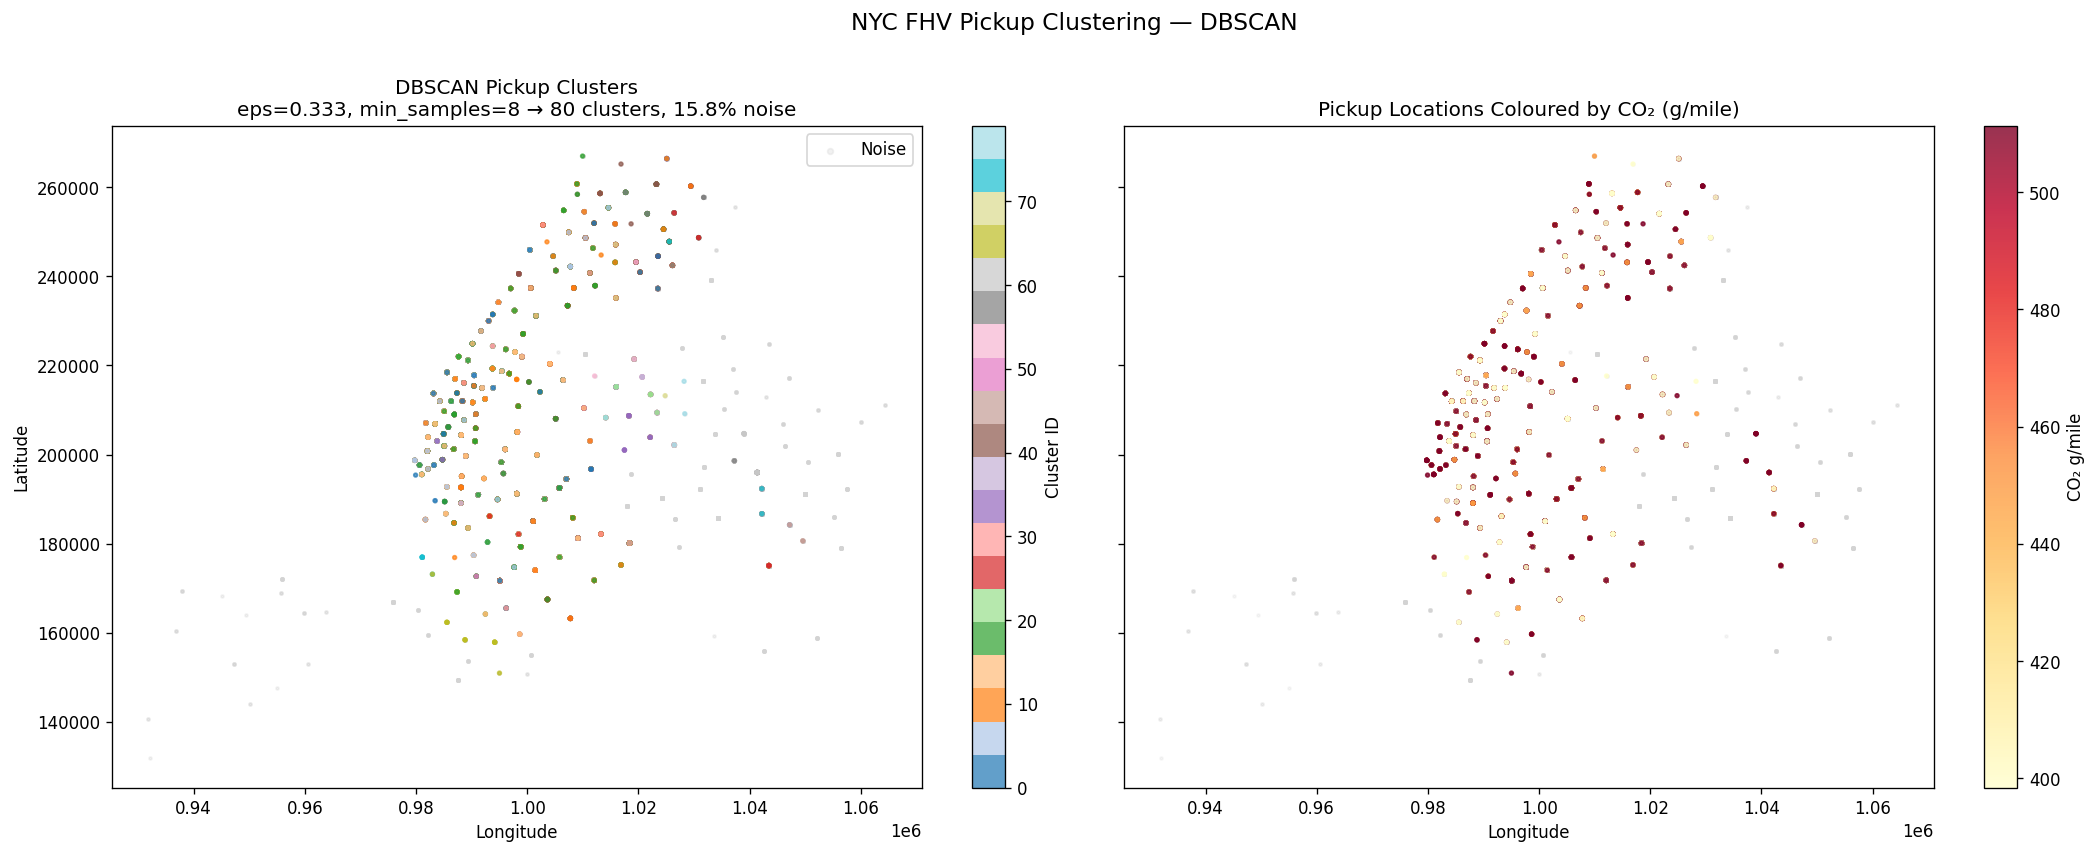

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True, sharey=True)

noise_mask   = df_train["dbscan_cluster"] == -1
cluster_mask = ~noise_mask

# cluster identity
axes[0].scatter(
    df_train.loc[noise_mask,   "pickup_lon"], df_train.loc[noise_mask,   "pickup_lat"],
    c="lightgrey", s=3, alpha=0.3, label="Noise"
)
sc = axes[0].scatter(
    df_train.loc[cluster_mask, "pickup_lon"], df_train.loc[cluster_mask, "pickup_lat"],
    c=df_train.loc[cluster_mask, "dbscan_cluster"], cmap="tab20", s=5, alpha=0.7
)
axes[0].set_title(f"DBSCAN Pickup Clusters\neps={EPSILON}, min_samples={MIN_SAMPLES} → {n_clusters} clusters, {noise_pct:.1f}% noise")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].legend(loc="upper right", markerscale=2)
plt.colorbar(sc, ax=axes[0], label="Cluster ID")

# colour by CO₂ g/mile to highlight high-emission clusters
co2_vals   = df_train.loc[cluster_mask, "co2TailpipeGpm"].fillna(df_train["co2TailpipeGpm"].median())
sc2 = axes[1].scatter(
    df_train.loc[noise_mask,   "pickup_lon"], df_train.loc[noise_mask,   "pickup_lat"],
    c="lightgrey", s=3, alpha=0.2
)
sc2 = axes[1].scatter(
    df_train.loc[cluster_mask, "pickup_lon"], df_train.loc[cluster_mask, "pickup_lat"],
    c=co2_vals, cmap="YlOrRd", s=5, alpha=0.8
)
axes[1].set_title("Pickup Locations Coloured by CO₂ (g/mile)")
axes[1].set_xlabel("Longitude")
plt.colorbar(sc2, ax=axes[1], label="CO₂ g/mile")

plt.suptitle("NYC FHV Pickup Clustering — DBSCAN", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/dbscan_map.png", bbox_inches="tight")
plt.show()

## Export Results

In [9]:
out_subset = "../Data/generated/trips_dbscan_labeled.csv"
df_train.to_csv(out_subset, index=False)
print(f"Saved {len(df_train):,} rows → {out_subset}")

dbscan_summary = {
    "algorithm":   "DBSCAN",
    "data_file":    DATA_PATH,
    "epsilon":      EPSILON,
    "min_samples":  MIN_SAMPLES,
    "n_clusters":   n_clusters,
    "noise_pct":    round(noise_pct, 2),
    "silhouette":   round(sil, 4) if not np.isnan(sil) else None,
    "subset_n":     len(df_train),
}
for k, v in dbscan_summary.items():
    print(f"  {k:15s}: {v}")

Saved 10,000 rows → ../Data/generated/trips_dbscan_labeled.csv
  algorithm      : DBSCAN
  data_file      : ../Data/raw/merged_trip_emissions_coordinates.csv
  epsilon        : 0.333
  min_samples    : 8
  n_clusters     : 80
  noise_pct      : 15.81
  silhouette     : -0.0963
  subset_n       : 10000


## DBSCAN Validation

Running DBSCAN on millions of rows at once builds a neighbor graph too large to fit in memory.

Partition by `PULocationID` (NYC's 263 taxi zones), run DBSCAN independently per zone, then assign globally-unique cluster IDs by offsetting per zone.

In [10]:
RANDOM_STATE_VAL = 23
df_validate = preprocess(df_full.sample(n = SUBSET_N, random_state = RANDOM_STATE_VAL).reset_index(drop=True))
X_raw = df_validate[features].values
X_val = scaler.fit_transform(X_raw)

EPSILON     = 0.333 
MIN_SAMPLES = 8   
# ──────────────────────────────────────────────────────────────────────────

db = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES, algorithm="ball_tree", n_jobs=-1)
df_validate["dbscan_cluster"] = db.fit_predict(X_val)

n_clusters = len(set(df_validate["dbscan_cluster"])) - (1 if -1 in df_validate["dbscan_cluster"].values else 0)
noise_pct  = (df_validate["dbscan_cluster"] == -1).mean() * 100
clustered  = df_validate[df_validate["dbscan_cluster"] != -1]

if n_clusters > 1 and len(clustered) > 1:
    sil = silhouette_score(
        X_val[clustered.index], clustered["dbscan_cluster"],
        sample_size=min(5000, len(clustered)), random_state=42
    )
else:
    sil = float("nan")

print(f"eps={EPSILON}, min_samples={MIN_SAMPLES}")
print(f"  Clusters found   : {n_clusters}")
print(f"  Noise points     : {noise_pct:.1f}%  ({int(noise_pct/100*len(df_validate)):,} rows)")
print(f"  Clustered points : {len(clustered):,}")
if not np.isnan(sil):
    print(f"  Silhouette score : {sil:.4f}  (target > 0.3)")
else:
    print("  Silhouette score : N/A (need >1 cluster)")


Full dataset : 2,062,185 rows
Working subset after cleaning: 10,000 rows
eps=0.333, min_samples=8
  Clusters found   : 72
  Noise points     : 16.4%  (1,640 rows)
  Clustered points : 8,360
  Silhouette score : -0.0675  (target > 0.3)


### Trained Model Results

| Metric           | Value   |
|------------------|--------|
| Clusters Found   | 80     |
| Noise Points     | 15.81% |
| Silhouette Score | -0.0963|

### Validation Model Results

| Metric           | Value   |
|------------------|--------|
| Clusters Found   | 72     |
| Noise Points     | 16.4%  |
| Silhouette Score | -0.0675|

Both the trained and validation model results yielded similar values for clusters found, noise points, and silhouette score, suggesting that the model is relatively stable and consistent across different samples. However, both silhouette scores are negative, indicating poor clustering quality and suggesting that this approach may not be well-suited for the dataset.